### Simple Linear Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
##Read the dataset
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

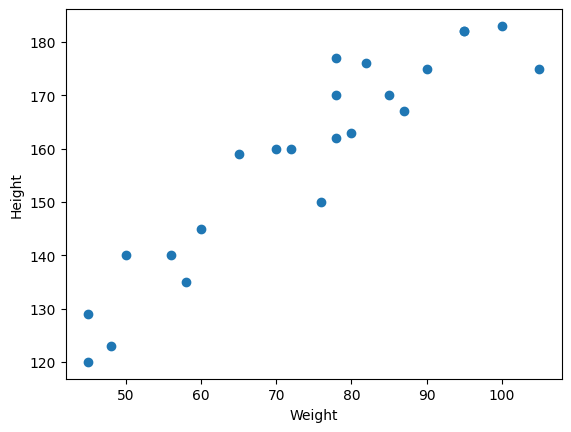

In [4]:
## Scatter PLot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight") #Independent
plt.ylabel("Height") #Dependent

In [26]:
## Aim -> Create a Best-Fit Line

# Divide the dataset into dependent and independent features

X = df[['Weight']] # independent features(2D)
y = df['Height'] # dependent features


In [27]:
## Train Test Split
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42)

In [29]:
X.shape

(23, 1)

In [30]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18, 1), (5, 1), (18,), (5,))

## Standardize the dataset Train independent  data


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform() 

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

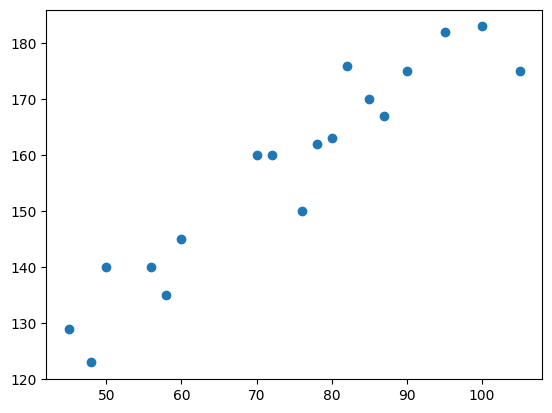

In [32]:
plt.scatter(X_train,y_train)

## Train the Simple Linear Regression

In [33]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [34]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
print("The slope or coefficient of weight is", regressor.coef_)
print("The Intercept is: ", regressor.intercept_)


The slope or coefficient of weight is [0.9630459]
The Intercept is:  85.96709053063559


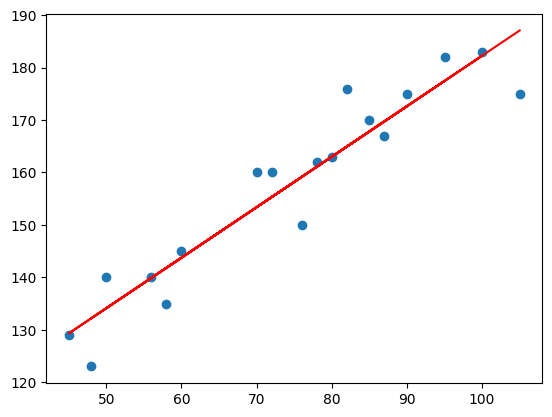

In [42]:
plt.scatter(X_train, y_train)
# for best fit line
plt.plot(X_train, regressor.predict(X_train), 'r')

### prediction of train data

1. predicted height output= intercept+coef_(Weights)
2. y_pred_train = 85.9670905 + 0.9630459(X_train)

### prediction of test data

1. predicted height output= intercept +coef_(Weights)
2. y_pred_test = 85.9670905 + 0.9630459(X_test)

In [45]:
y_pred_test = regressor.predict(X_test)


In [46]:
y_pred_test, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

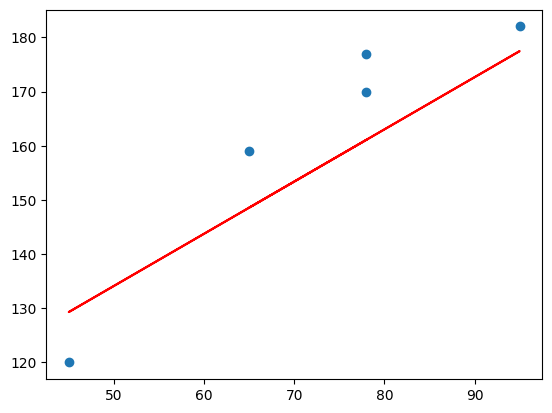

In [47]:
plt.scatter(X_test,y_test)
plt.plot(X_test, regressor.predict(X_test), 'r')

### Performance Metrics

## MSE, MAE, RMSE
## R square and adjusted R square

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [50]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051658
9.822657814519232
10.477400726827078


## R Square

R^2 = 1 - SSR/SST

R^2 = coefficient of determination SSR = sum of squares of residuales SST = total sum of squares


In [51]:
score = r2_score(y_test, y_pred_test)
score

0.776986986042344

### Adjusted R2

### Adjusted R21 [(1-R2) (n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [53]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

In [54]:
regressor

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
# new data point weight is 80
scaled_weight = scaler.transform([[80]])
scaled_weight

c:\Users\Lenovo\Desktop\Python For DS\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [63]:
print("The hieight prediction for wt 80kg is:", regressor.predict([scaled_weight[0]]))

The hieight prediction for wt 80kg is: [86.27864331]


c:\Users\Lenovo\Desktop\Python For DS\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


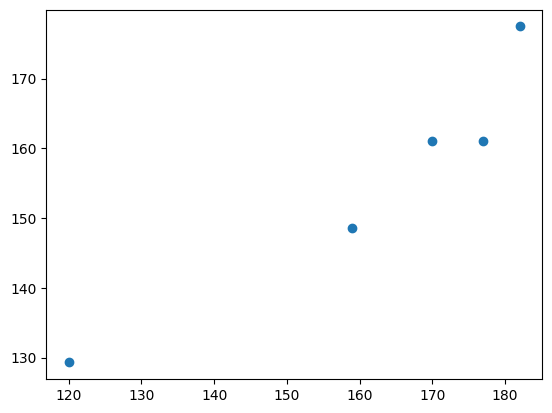

In [64]:
## Assumptions
plt.scatter(y_test, y_pred_test)

In [65]:
## Residuals
residuals = y_test - y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

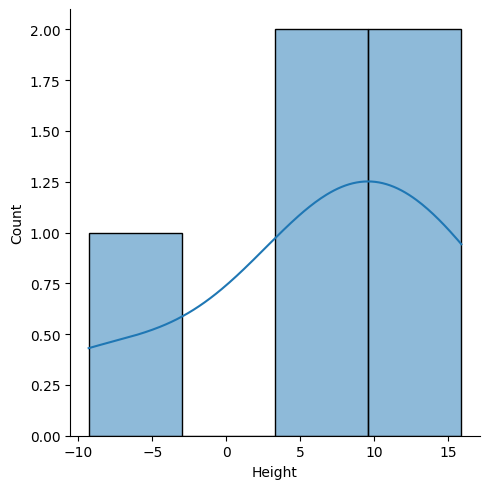

In [67]:
## Plot this residuals
import seaborn as sns
sns.displot(residuals, kde=True)

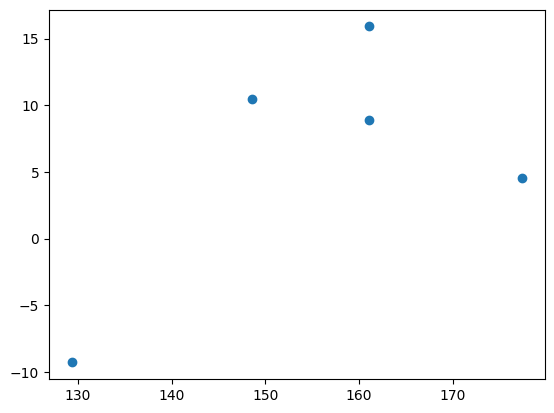

: 

In [ ]:
plt.scatter(y_pred_test, residuals)